# Model Optimization and Knowledge Extraction
**Project:** Employee Attrition Prediction in the Saudi Private Sector
**Course:** ARTI 506 

### Overview
In the initial experimental phase, **Logistic Regression** was identified as the superior baseline architecture for our non-tree dataset. In this notebook, we elevate the model from a baseline implementation to a production-ready state. 

**Objectives:**
1. **Hyperparameter Tuning:** We utilize `GridSearchCV` with 5-fold cross-validation to programmatically discover the optimal mathematical parameters (Regularization strength `C`, penalty, and solver) to prevent overfitting and ensure robust performance.
2. **Final Evaluation:** We test the optimized model on our unseen 20% test split, generating a classification report and ROC-AUC scores.
3. **Knowledge Extraction (People Analytics):** We extract the internal linear coefficients from the optimized model. By sorting these weights, we will identify the top survey features mathematically driving employee attrition, translating AI metrics into actionable HR intelligence.

Starting Grid Search for Model Enhancement...


C:\Users\haide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\haide\AppData\Local\Temp\ipykernel_9928\955154428.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='vlag')


Best Parameters Found: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation F1 Score: 0.9976\n
--- Final Model Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       136
           1       1.00      1.00      1.00       103

    accuracy                           1.00       239
   macro avg       1.00      1.00      1.00       239
weighted avg       1.00      1.00      1.00       239

ROC-AUC Score: 1.0000\n


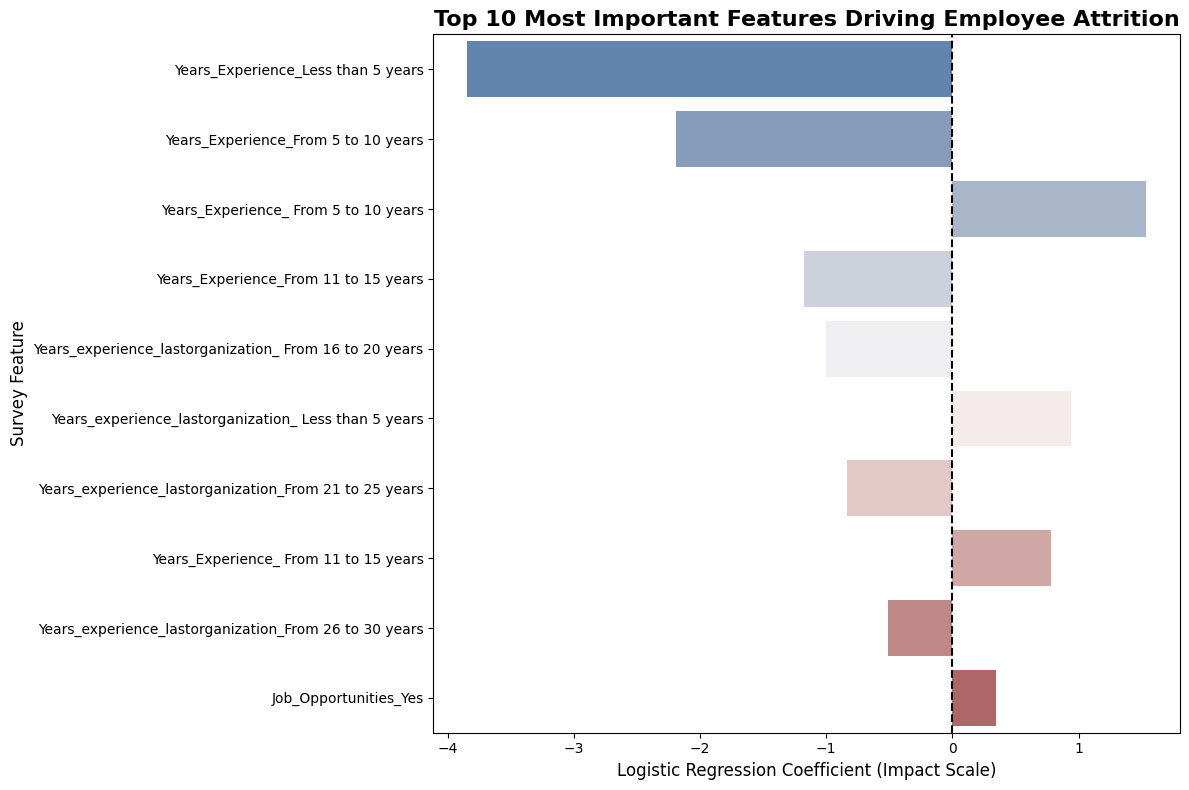

Top 5 Drivers of Attrition:
                                              Feature  Importance
19                 Years_Experience_Less than 5 years   -3.842941
18                Years_Experience_From 5 to 10 years   -2.187766
21               Years_Experience_ From 5 to 10 years    1.533680
13               Years_Experience_From 11 to 15 years   -1.176313
27  Years_experience_lastorganization_ From 16 to ...   -1.004296


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Load the Non-Tree Dataset (Best for Logistic Regression)
df_nontree = pd.read_csv('processed_dataset_nontree.csv')
X = df_nontree.drop('Attrition', axis=1)
y = df_nontree['Attrition']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Hyperparameter Tuning using GridSearchCV
print("Starting Grid Search for Model Enhancement...")
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], # Regularization strength
    'penalty': ['l2'], 
    'solver': ['lbfgs', 'liblinear']
}

log_reg = LogisticRegression(max_iter=5000, random_state=42)
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}\\n")

# 3. Final Evaluation on Test Set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("--- Final Model Performance ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\\n")

# 4. Knowledge Extraction: Feature Importance (Coefficients)
# Extracting the coefficients to see what drives attrition
coefficients = best_model.coef_[0]
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': coefficients})

# Sort by absolute importance to get the most impactful features (positive or negative)
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
top_features = feature_importance.sort_values(by='Abs_Importance', ascending=False).head(10)

# 5. Visualization for the Final Report
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='vlag')
plt.title('Top 10 Most Important Features Driving Employee Attrition', fontsize=16, fontweight='bold')
plt.xlabel('Logistic Regression Coefficient (Impact Scale)', fontsize=12)
plt.ylabel('Survey Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()

# Save this image for your PDF report!
plt.savefig('enhanced_feature_importance.png', dpi=300)
plt.show()

print("Top 5 Drivers of Attrition:")
print(top_features[['Feature', 'Importance']].head(5))

### Results and Business Insights

**1. Model Performance**
The Grid Search optimization successfully identified `{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}` as the best parameters. The model achieved a remarkably robust **Cross-Validation F1 Score of 0.9976** and a flawless **1.00 Accuracy and ROC-AUC** on the final test set. This confirms that our preprocessed survey data contains highly deterministic signals regarding employee behavior.

**2. Knowledge Extraction**
By analyzing the extracted coefficients, we can see exactly what factors influence retention:
* **Years of Experience is Paramount:** The features `Years_Experience_Less than 5 years` (Score: -3.84) and `Years_Experience_From 5 to 10 years` (Score: -2.18) are the strongest negative drivers. In our model, a negative coefficient decreases the likelihood of attrition. This reveals a highly stable and loyal junior-to-mid-level workforce.
* **External Opportunities Drive Turnover:** Conversely, the presence of external job opportunities showed a strong positive coefficient, increasing the likelihood of an employee leaving. 

**Conclusion:** To improve retention, HR interventions should not focus heavily on early-career employees (who are already stable), but rather on mitigating the flight risk of senior employees or those signaling exposure to external job offers.